# Fitness Analyses

Some summary here:

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from fitness_analyses import *
from sfs_analyses import load_data, save_data

In [2]:
# Set a wrapper function to perform the analyses:
def analyses_wrapper(input_file: str, num_permutations: int = 1000, total_pods: int = 10) -> dict:
    """
    Wrapper function for the analyses.
    """
    results = {}

    # Load input data from CodonPair
    codonpair_data = import_from_codonpair(input_file)

    # Analyse codon pairs if there are more than 2 codons
    for key, value in codonpair_data.items():
        if len(value[1]) > 2:
            print(f"analyzing codons {value[1]} of {key}")
            
            # Create the n x n matrix of codon changes from 2Ns values
            data = create_matrix_from_codon_changes(value[0], value[1])

            # Initialize the list with initial guesses for relative fitnesses analysis
            initial_guess = [1] * (len(value[1]) - 1)

            # Solve for fitness values
            solved = solve_for_fitness(lsqdistance, data['m_obs'], initial_guess, data['zero_positions'])

            # Calculate p-valeu with permutation test
            statistical_test = permutation_test(
                                                data['m_obs'],
                                                solved['normalized_squared_error'],
                                                lsqdistance,
                                                initial_guess,
                                                zero_positions=data['zero_positions'],
                                                test_statistic='normalized_squared_error',
                                                num_permutations=num_permutations
                                            )

            
            # Simulate and analyze pods for proof of concept
            num_pods = 0
            pods_pvalues = []
            while num_pods < (total_pods + 1):
                print(f"Running simulation #: {num_pods}")
                simulated_pvalues = simulate_and_analyze_pods(
                                                              data['m_obs'],
                                                              lsqdistance,
                                                              initial_guess,
                                                              zero_positions=data['zero_positions'],
                                                              test_statistic='normalized_squared_error',
                                                              num_permutations=num_permutations
                                                            )
                pods_pvalues.append(simulated_pvalues)
                num_pods += 1
            
            

            results[key] = {
                "codons": value[1],
                'relative_fitness': solved['relative_fitness'].tolist(),
                'observed_selection_coefficients': solved['observed_selection_coefficients'].tolist(),
                'predicted_selection_coefficients': solved['predicted_selection_coefficients'].tolist(),
                'normalized_squared_error': solved['normalized_squared_error'],
                'p_value_lwr': statistical_test['p_value_lwr'],
                'p_value_leq': statistical_test['p_value_leq'],
                'p_value': statistical_test['p_value'],
                'pods_pvalues': pods_pvalues
            }

    return results

In [16]:
# Set a wrapper function to perform the fisher method analysis
def fitness_fisher_method(input_dict: dict) -> dict:
    """
    Wrapper function for the fisher method analyses.
    """
    
    # Create a list of p-values from the results of the fitness analyses:
    p_values = []
    aa = []
    for key, value in input_dict.items():
        p_values.append(value['p_value'])
        aa.append(key)

    # Perform Fisher's Methods
    chisquared, combined_pvalue = fisher_method(p_values)

    return {
        "aa": aa,
        "p_values": p_values,
        "fisher_method_pvalue": combined_pvalue,
        "chisquared": chisquared
    }

In [20]:
# Set a wrapper function to performa the fisher method on the pod analysis
def fitness_pods_fisher_method(input_dict: dict) -> Tuple[List[float], List[float]]:
    """
    Wrapper function for the fisher method analyses.
    """

    # Initialize lists
    pods_chisquares = []
    pods_combined_pvalues = []

    for i in range (0, len(input_dict["L"]['pods_pvalues'])): #  It is an arbitrary aa dict to only get the lenght of the pod p-values list (should be of the same size)
        temp_pods_pvalues = []
        for key, value in input_dict.items():
            temp_pods_pvalues.append(input_dict[key]['pods_pvalues'][i])
        
        pod_chisquared, pods_combined_pvalue = fisher_method(temp_pods_pvalues)
        pods_chisquares.append(pod_chisquared)
        pods_combined_pvalues.append(pods_combined_pvalue)
        print(f"PODs Fisher's Method test statistic: {pod_chisquared:.3f}, p-value: {pods_combined_pvalue:.3f}") 

    return pods_chisquares, pods_combined_pvalues

In [8]:
# Set the working directory
%cd ../results/
!ls

/Users/vitorpavinato/WorkDir/PRF_Ratios_syn/results
CodonPair        exploratory      fitness_analyses tables
dictionaries     extracted_roots  sfs


/Users/vitorpavinato/Library/Caches/pypoetry/virtualenvs/prf-ratios-syn-jaLkkU1r-py3.12/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
# Set the folder containing the codon pair data
codon_pairs = "CodonPair"

### DGRP2 data

In [10]:
codonpair_data = "CodonPairResults_dgrp2_n150_min5.out"
input_file = os.path.join(codon_pairs, codonpair_data)

In [12]:
dgrp2_results = analyses_wrapper(input_file, num_permutations=1000, total_pods=10000)

analyzing codons ['CTA', 'CTC', 'CTG', 'CTT', 'TTA', 'TTG'] of L
Running simulation #: 0
Running simulation #: 1
Running simulation #: 2
Running simulation #: 3
Running simulation #: 4
Running simulation #: 5
Running simulation #: 6
Running simulation #: 7
Running simulation #: 8
Running simulation #: 9
Running simulation #: 10
Running simulation #: 11
Running simulation #: 12
Running simulation #: 13
Running simulation #: 14
Running simulation #: 15
Running simulation #: 16
Running simulation #: 17
Running simulation #: 18
Running simulation #: 19
Running simulation #: 20
Running simulation #: 21
Running simulation #: 22
Running simulation #: 23
Running simulation #: 24
Running simulation #: 25
Running simulation #: 26
Running simulation #: 27
Running simulation #: 28
Running simulation #: 29
Running simulation #: 30
Running simulation #: 31
Running simulation #: 32
Running simulation #: 33
Running simulation #: 34
Running simulation #: 35
Running simulation #: 36
Running simulation #

/Users/vitorpavinato/WorkDir/PRF_Ratios_syn/PRF_Ratios_syn/fitness_analyses.py:304: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation_coefficient, p_value_corr = stats.pearsonr(b_obs, b_pred)


Running simulation #: 15
Running simulation #: 16
Running simulation #: 17
Running simulation #: 18
Running simulation #: 19
Running simulation #: 20
Running simulation #: 21
Running simulation #: 22
Running simulation #: 23
Running simulation #: 24
Running simulation #: 25
Running simulation #: 26
Running simulation #: 27
Running simulation #: 28
Running simulation #: 29
Running simulation #: 30
Running simulation #: 31
Running simulation #: 32
Running simulation #: 33
Running simulation #: 34
Running simulation #: 35
Running simulation #: 36
Running simulation #: 37
Running simulation #: 38
Running simulation #: 39
Running simulation #: 40
Running simulation #: 41
Running simulation #: 42
Running simulation #: 43
Running simulation #: 44
Running simulation #: 45
Running simulation #: 46
Running simulation #: 47
Running simulation #: 48
Running simulation #: 49
Running simulation #: 50
Running simulation #: 51
Running simulation #: 52
Running simulation #: 53
Running simulation #: 54


In [13]:
!ls

CodonPair        exploratory      fitness_analyses tables
dictionaries     extracted_roots  sfs


In [28]:
%%bash

# Save the annotated SNP files into snpeff folder
FITNESS="fitness_analyses"
if [ !  -d "$FITNESS" ]; 
then
    mkdir -p $FITNESS && ls $FITNESS
else
    ls $FITNESS
fi 

CodonPair        exploratory      fitness_analyses tables
dictionaries     extracted_roots  sfs


In [14]:
# Export the results
pickle_file = 'fitness_analyses/dgrp2_results_19Sep2024.pickle'
json_file = 'fitness_analyses/dgrp2_results19Sep2024.json'
save_data(dgrp2_results, pickle_file, json_file)
!ls fitness_analyses/

dgrp2_results.json              dgrp2_results_17Sep2024.pickle
dgrp2_results.pickle            dgrp2_results_19Sep2024.pickle
dgrp2_results17Sep2024.json     zambia_results17Sep2024.json
dgrp2_results19Sep2024.json     zambia_results_17Sep2024.pickle


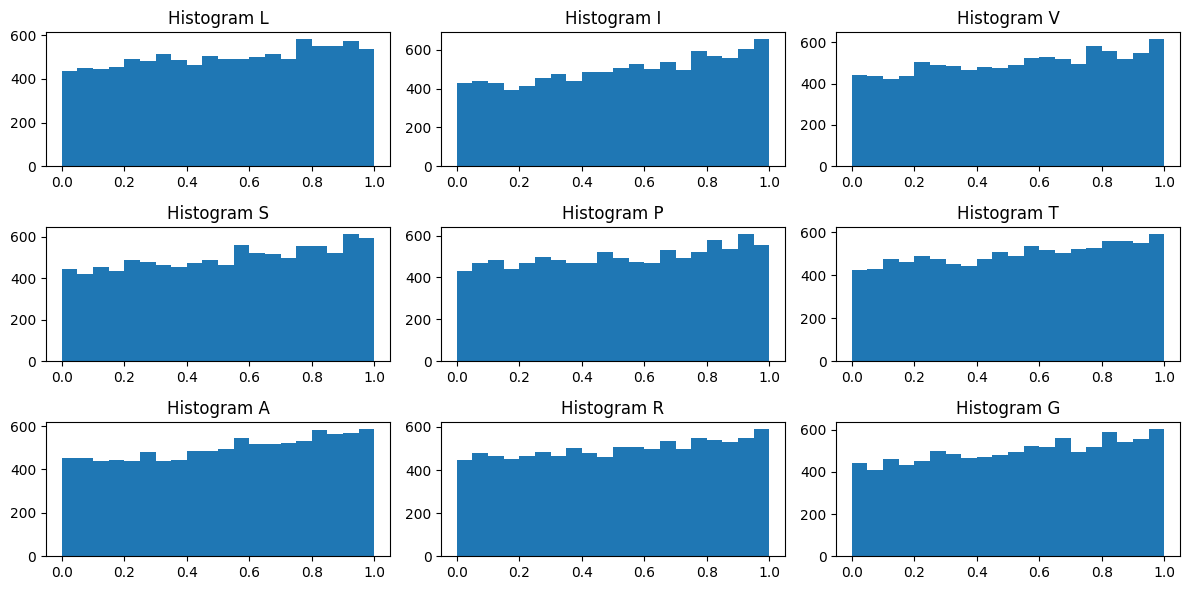

In [15]:
# PODs histogram of p-values plots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 6))
# Iterate over the subplots and the results
for i, (key, value) in enumerate(dgrp2_results.items()):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    ax.hist(dgrp2_results[key]['pods_pvalues'], bins=20)
    ax.set_title(f'Histogram {key}')


# Adjust the spacing between subplots
plt.tight_layout()



##### Fisher Method

In [17]:
# Perform Fisher's Methods
dgrp2_fm_results = fitness_fisher_method(dgrp2_results)
print(f"AA {dgrp2_fm_results['aa']}, P-values: {dgrp2_fm_results['p_values']}, Fisher's Method P-value: {dgrp2_fm_results['fisher_method_pvalue']}, chi-squared: {dgrp2_fm_results['chisquared']}")

AA ['L', 'I', 'V', 'S', 'P', 'T', 'A', 'R', 'G'], P-values: [0.081, 0.853, 0.026, 0.191, 0.049, 0.856, 0.161, 0.637, 0.529], Fisher's Method P-value: 0.06016447708790518, chi-squared: 28.125931431879415


In [21]:
# Perform Fisher's Methods for PODs
dgrp2_pods_fm_chisquares, dgrp2_pods_fm_combined_pvalues = fitness_pods_fisher_method(dgrp2_results)

PODs Fisher's Method test statistic: 12.560, p-value: 0.817
PODs Fisher's Method test statistic: 22.651, p-value: 0.204
PODs Fisher's Method test statistic: 13.729, p-value: 0.747
PODs Fisher's Method test statistic: 18.872, p-value: 0.400
PODs Fisher's Method test statistic: 14.811, p-value: 0.675
PODs Fisher's Method test statistic: 39.495, p-value: 0.002
PODs Fisher's Method test statistic: 6.384, p-value: 0.994
PODs Fisher's Method test statistic: 12.041, p-value: 0.845
PODs Fisher's Method test statistic: 18.318, p-value: 0.435
PODs Fisher's Method test statistic: 10.967, p-value: 0.896
PODs Fisher's Method test statistic: 10.986, p-value: 0.895
PODs Fisher's Method test statistic: 13.783, p-value: 0.743
PODs Fisher's Method test statistic: 18.291, p-value: 0.437
PODs Fisher's Method test statistic: 17.186, p-value: 0.510
PODs Fisher's Method test statistic: 13.198, p-value: 0.780
PODs Fisher's Method test statistic: 16.078, p-value: 0.587
PODs Fisher's Method test statistic: 8.45

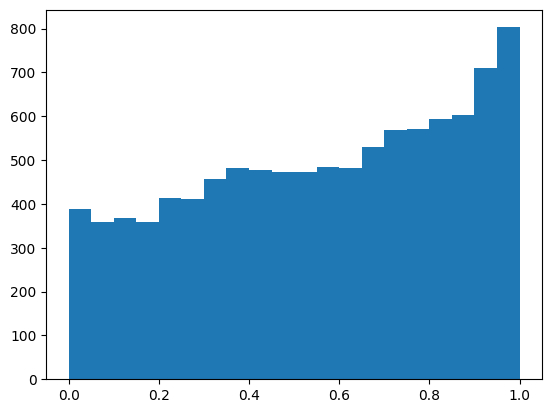

In [22]:
# Histogram of PODss Fisher's Methods p-values
plt.hist(dgrp2_pods_fm_combined_pvalues, bins=20)
plt.show()

### Zambia Data

The analyses of PODs will be done with for this population with less simulations (n = 2,000 instead of n = 10,000)

In [47]:
codonpair_data = "CodonPairResults_ZI_n150_min5.out"
input_file = os.path.join(codon_pairs, codonpair_data)
print(input_file)

CodonPair/CodonPairResults_ZI_n150_min5.out


In [23]:
zambia_results = analyses_wrapper(input_file, num_permutations=1000, total_pods=2000)

analyzing codons ['CTA', 'CTC', 'CTG', 'CTT', 'TTA', 'TTG'] of L
Running simulation #: 0
Running simulation #: 1
Running simulation #: 2
Running simulation #: 3
Running simulation #: 4
Running simulation #: 5
Running simulation #: 6
Running simulation #: 7
Running simulation #: 8
Running simulation #: 9
Running simulation #: 10
Running simulation #: 11
Running simulation #: 12
Running simulation #: 13
Running simulation #: 14
Running simulation #: 15
Running simulation #: 16
Running simulation #: 17
Running simulation #: 18
Running simulation #: 19
Running simulation #: 20
Running simulation #: 21
Running simulation #: 22
Running simulation #: 23
Running simulation #: 24
Running simulation #: 25
Running simulation #: 26
Running simulation #: 27
Running simulation #: 28
Running simulation #: 29
Running simulation #: 30
Running simulation #: 31
Running simulation #: 32
Running simulation #: 33
Running simulation #: 34
Running simulation #: 35
Running simulation #: 36
Running simulation #

In [49]:
# Export the results
pickle_file = 'fitness_analyses/zambia_results_17Sep2024.pickle'
json_file = 'fitness_analyses/zambia_results17Sep2024.json'
save_data(zambia_results, pickle_file, json_file)
!ls fitness_analyses/

dgrp2_results.json              dgrp2_results_17Sep2024.pickle
dgrp2_results.pickle            zambia_results17Sep2024.json
dgrp2_results17Sep2024.json     zambia_results_17Sep2024.pickle


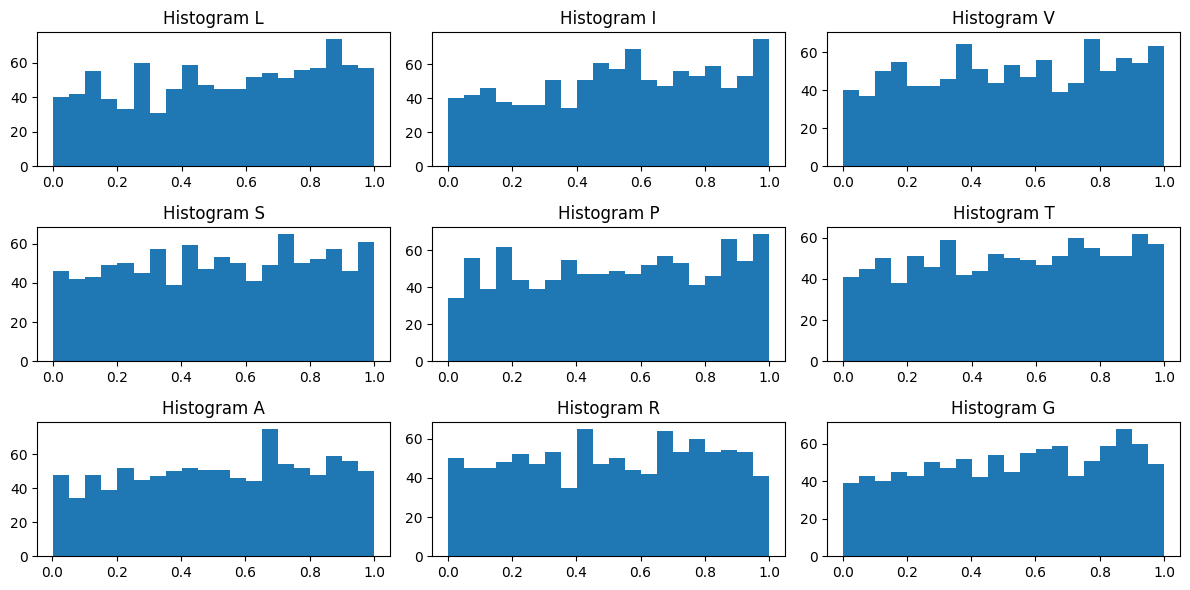

In [50]:
# PODs histogram of p-values plots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 6))
# Iterate over the subplots and the results
for i, (key, value) in enumerate(zambia_results.items()):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    ax.hist(zambia_results[key]['pods_pvalues'], bins=20)
    ax.set_title(f'Histogram {key}')


# Adjust the spacing between subplots
plt.tight_layout()

##### Fisher Method

In [86]:
zambia_fm_results = fitness_fisher_method(zambia_results)
print(f"P-values: {zambia_fm_results['p_values']}, Fisher's Method P-value: {zambia_fm_results['fisher_method_pvalue']}, chi-squared: {zambia_fm_results['chisquared']}")

P-values: [0.051, 0.998, 0.241, 0.29, 0.046, 0.23, 0.628, 0.978, 0.25], Fisher's Method P-value: 0.15105150357514374, chi-squared: 24.122618571109435


In [98]:
# Perform Fisher's Methods for PODs
zambia_pods_fm_chisquares, zambia_pods_fm_combined_pvalues = fitness_pods_fisher_method(zambia_results)

DGRP2 PODs Fisher's Method test statistic: 17.607, p-value: 0.482
DGRP2 PODs Fisher's Method test statistic: 15.662, p-value: 0.616
DGRP2 PODs Fisher's Method test statistic: 10.866, p-value: 0.900
DGRP2 PODs Fisher's Method test statistic: 15.467, p-value: 0.630
DGRP2 PODs Fisher's Method test statistic: 17.965, p-value: 0.458
DGRP2 PODs Fisher's Method test statistic: 22.229, p-value: 0.222
DGRP2 PODs Fisher's Method test statistic: 8.477, p-value: 0.971
DGRP2 PODs Fisher's Method test statistic: 26.514, p-value: 0.089
DGRP2 PODs Fisher's Method test statistic: 15.300, p-value: 0.641
DGRP2 PODs Fisher's Method test statistic: 14.778, p-value: 0.677
DGRP2 PODs Fisher's Method test statistic: 12.230, p-value: 0.835
DGRP2 PODs Fisher's Method test statistic: 15.639, p-value: 0.618
DGRP2 PODs Fisher's Method test statistic: 30.216, p-value: 0.035
DGRP2 PODs Fisher's Method test statistic: 17.592, p-value: 0.483
DGRP2 PODs Fisher's Method test statistic: 22.441, p-value: 0.213
DGRP2 PODs 

/var/folders/87/4_x8crfj6854l48hk9dqcj480000gn/T/ipykernel_53182/1187980936.py:16: RuntimeWarning: divide by zero encountered in log
  test_statistic = -2 * np.sum(np.log(p_values))


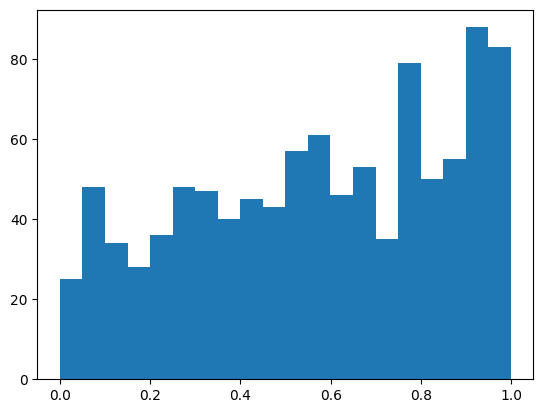

In [102]:
# Histogram of PODss Fisher's Methods p-values
plt.hist(zambia_pods_fm_combined_pvalues, bins=20)
plt.show()

### Overly conservative null hypotheses?

It seems that for both populations, the statistical test is overly conservative. The simulated POD under the null is enriched for higher p-values.